# Default-Parameter Baseline Models for City-Level TCI Prediction

This notebook builds a simple baseline comparison for the city-grid monthly TCI prediction task. The goal is to answer a practical question: **how much does hyperparameter tuning improve the model compared with reasonable default model settings?**

Each row in the modelling data represents one city-grid-month observation. The prediction target is raw `tci`; it is not log-transformed and no tail trimming is applied. The same feature set and the same temporal train/validation/test split are used as in the main tuned modelling workflow, so the only intended difference is whether model hyperparameters are tuned.

Workflow:

1. Load one processed prediction panel for each city.
2. Rebuild the same engineered predictors used in the main model: environmental variables, static urban variables, POI/road composition features, and geographic features.
3. Split each city by time: January-August for training, September-October for validation, and November-December for final testing.
4. Train several default-parameter baseline models without hyperparameter search.
5. Select the best default baseline using validation RMSE only.
6. Refit the selected default baseline on January-October and evaluate it once on November-December.
7. Compare the default baseline with the main tuned model to check whether tuning adds meaningful predictive value.

The held-out test months are used only for final reporting. They are not used to choose the default model or to change the tuned model after seeing results.


In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
    XGBOOST_IMPORT_ERROR = None
except Exception as exc:
    XGBRegressor = None
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = exc

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
TARGET_COL = "tci"
CITY_COL = "city"
SPATIAL_ID_COL = "spatial_id"
YEAR_COL = "year"
MONTH_COL = "month"

def find_project_root(start=None) -> Path:
    """Find the NO2_Mobility_Project root from the current notebook location."""
    current = (start or Path.cwd()).resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / "data").exists() and (candidate / "ml_model_training_and_evaluation").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Run this notebook from within the "
        "NO2_Mobility_Project folder or one of its subfolders."
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
PANEL_DIR = DATA_DIR / "PanelProcessed"

OUTPUT_ROOT = DATA_DIR / "ModelOutputs" / "tci_city_models_default_baseline_v32"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

SCENARIO_ID = "default_baseline_compare_with_v27_train_jan_aug_validate_sep_oct_test_nov_dec_with_month"
SCENARIO_OUTPUT_ROOT = OUTPUT_ROOT / SCENARIO_ID
SCENARIO_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

MAIN_MODEL_OUTPUT_ROOT = DATA_DIR / "ModelOutputs" / "tci_city_models_with_geo_raw_full_range_v27"
MAIN_MODEL_SCENARIO_ID = "raw_tci_full_range_train_jan_aug_validate_sep_oct_test_nov_dec_with_month"
MAIN_MODEL_METRICS_PATH = MAIN_MODEL_OUTPUT_ROOT / MAIN_MODEL_SCENARIO_ID / "all_city_metrics.csv"

CITY_PANEL_FILES = {
    path.name.replace("_prediction_model_panel.csv", ""): path
    for path in sorted(PANEL_DIR.glob("*_prediction_model_panel.csv"))
}

if not CITY_PANEL_FILES:
    raise FileNotFoundError(f"No prediction model panels found in {PANEL_DIR}")

RUN_CITIES = list(CITY_PANEL_FILES)

print(f"Cities found: {len(RUN_CITIES)}")
print(RUN_CITIES)
print("Output folder:", SCENARIO_OUTPUT_ROOT)
print("Main tuned model metrics found:", MAIN_MODEL_METRICS_PATH.exists())


Cities found: 8
['baghdad', 'buenos_aires', 'cairo', 'dakar', 'lima', 'mexico_city', 'mumbai', 'new_york']
Output folder: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_default_baseline_v32/default_baseline_compare_with_v27_train_jan_aug_validate_sep_oct_test_nov_dec_with_month
Main tuned model metrics found: True


## 1. Load City Prediction Panels

This section reads the processed panel files used for modelling. Each file should contain monthly grid-level observations for one city, including:

- identifiers: `city`, `spatial_id`, `year`, and `month`;
- target variable: `tci`;
- dynamic predictors such as `no2`, temperature, wind speed, and holiday count;
- static urban predictors such as population, roads, public transport, POIs, and building height;
- geographic coordinates such as grid centroid longitude and latitude.

The loading step prints the available cities and basic panel dimensions so that the modelling sample is transparent before fitting any model.


In [2]:
city_panels = {}
load_summary_rows = []

for city in RUN_CITIES:
    path = CITY_PANEL_FILES[city]
    if not path.exists():
        raise FileNotFoundError(f"Missing city panel for {city}: {path}")

    panel = pd.read_csv(path)
    panel[CITY_COL] = panel[CITY_COL].astype(str)
    panel[SPATIAL_ID_COL] = panel[SPATIAL_ID_COL].astype(str)
    panel[YEAR_COL] = pd.to_numeric(panel[YEAR_COL], errors="coerce").astype(int)
    panel[MONTH_COL] = pd.to_numeric(panel[MONTH_COL], errors="coerce").astype(int)
    city_panels[city] = panel

    load_summary_rows.append({
        "city": city,
        "rows": len(panel),
        "spatial_ids": panel[SPATIAL_ID_COL].nunique(),
        "months": sorted(panel[MONTH_COL].unique().tolist()),
        "columns": panel.shape[1],
        "tci_missing_rows": int(panel[TARGET_COL].isna().sum()) if TARGET_COL in panel.columns else np.nan,
        "wind_missing_rows": int(panel["wind_speed"].isna().sum()) if "wind_speed" in panel.columns else np.nan,
        "centroid_lon_missing_rows": int(panel["centroid_lon"].isna().sum()) if "centroid_lon" in panel.columns else np.nan,
        "centroid_lat_missing_rows": int(panel["centroid_lat"].isna().sum()) if "centroid_lat" in panel.columns else np.nan,
    })

load_summary_df = pd.DataFrame(load_summary_rows)
load_summary_path = SCENARIO_OUTPUT_ROOT / "loaded_panel_summary.csv"
load_summary_df.to_csv(load_summary_path, index=False)
print("Saved load summary:", load_summary_path)
display(load_summary_df)


Saved load summary: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_default_baseline_v32/default_baseline_compare_with_v27_train_jan_aug_validate_sep_oct_test_nov_dec_with_month/loaded_panel_summary.csv


,city,rows,spatial_ids,months,columns,tci_missing_rows,wind_missing_rows,centroid_lon_missing_rows,centroid_lat_missing_rows
0,baghdad,34138,3737,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,0,0,0
1,buenos_aires,38323,3753,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,1801,0,0
2,cairo,25959,2964,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,0,0,0
3,dakar,3681,380,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,0,0,0
4,lima,10732,1032,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,0,0,0
5,mexico_city,41319,4680,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,0,0,0
6,mumbai,3108,506,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,0,0,0
7,new_york,9467,795,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",30,0,621,0,0


## 2. Rebuild the Model Feature Set

This section creates the explanatory variables used by the baseline models. The target remains raw `tci`; transformations are applied only to predictors.

The feature engineering includes:

- core dynamic predictors: NO₂, ERA5 temperature, wind speed, month, and holiday count;
- static urban-form variables: population, building height, roads, public transport, POIs, and power plants;
- log-transformed scale variables, such as `log_population`, `log_road_length_total_m`, and `log_poi_total`;
- composition features, such as road-type shares and POI-category shares;
- geographic features, including centroid coordinates, centered coordinates, kilometer-scale offsets, and distance to the city center.

This keeps the default baseline directly comparable with the tuned model, because both use the same input information.


In [3]:
ROAD_LENGTH_COLS = [
    "road_length_motorway_m",
    "road_length_primary_m",
    "road_length_residential_m",
    "road_length_secondary_m",
    "road_length_tertiary_m",
    "road_length_trunk_m",
    "road_length_unclassified_m",
]

POI_COLS = [
    "poi_business_n_business",
    "poi_commercial_n_commercial",
    "poi_education_n_education",
    "poi_leisure_n_leisure",
]

SPATIAL_BASE_COLS = ["centroid_lon", "centroid_lat"]
SPATIAL_ENGINEERED_COLS = [
    "centroid_lon_centered",
    "centroid_lat_centered",
    "centroid_x_km_from_city_center",
    "centroid_y_km_from_city_center",
    "distance_to_city_center_km",
]

BASE_FEATURE_COLS = [
    "no2",
    "era5_temp",
    "month",
    "centroid_lon",
    "centroid_lat",
    "holiday_is_off_days",
    "wind_speed",
    "population",
    "building_height",
    "pt_count_points",
    "pt_count_lines",
    "pt_count_polygon",
    "pt_total",
    "road_length_motorway_m",
    "road_length_primary_m",
    "road_length_residential_m",
    "road_length_secondary_m",
    "road_length_tertiary_m",
    "road_length_trunk_m",
    "road_length_unclassified_m",
    "road_length_total_m",
    "poi_business_n_business",
    "poi_commercial_n_commercial",
    "poi_education_n_education",
    "poi_leisure_n_leisure",
    "power_plant_n_power_plant",
]


def safe_log1p(series: pd.Series) -> pd.Series:
    return np.log1p(series.clip(lower=0))


def add_engineered_features(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    out = df.copy()

    unique_grid_locations = (
        out[[SPATIAL_ID_COL, "centroid_lon", "centroid_lat"]]
        .drop_duplicates(subset=[SPATIAL_ID_COL])
        .dropna(subset=["centroid_lon", "centroid_lat"])
    )
    city_lon_center = unique_grid_locations["centroid_lon"].mean()
    city_lat_center = unique_grid_locations["centroid_lat"].mean()
    km_per_degree_lat = 111.32
    km_per_degree_lon = 111.32 * np.cos(np.deg2rad(city_lat_center))

    out["centroid_lon_centered"] = out["centroid_lon"] - city_lon_center
    out["centroid_lat_centered"] = out["centroid_lat"] - city_lat_center
    out["centroid_x_km_from_city_center"] = out["centroid_lon_centered"] * km_per_degree_lon
    out["centroid_y_km_from_city_center"] = out["centroid_lat_centered"] * km_per_degree_lat
    out["distance_to_city_center_km"] = np.sqrt(
        out["centroid_x_km_from_city_center"] ** 2
        + out["centroid_y_km_from_city_center"] ** 2
    )

    out["log_population"] = safe_log1p(out["population"])
    out["log_pt_total"] = safe_log1p(out["pt_total"])
    out["log_road_length_total_m"] = safe_log1p(out["road_length_total_m"])
    out["log_power_plant_n_power_plant"] = safe_log1p(out["power_plant_n_power_plant"])

    out["poi_total"] = out[POI_COLS].sum(axis=1)
    out["log_poi_total"] = safe_log1p(out["poi_total"])

    road_total = out["road_length_total_m"].replace(0, np.nan)
    for col in ROAD_LENGTH_COLS:
        out[f"{col}_share"] = (out[col] / road_total).fillna(0)

    poi_total = out["poi_total"].replace(0, np.nan)
    for col in POI_COLS:
        out[f"{col}_share"] = (out[col] / poi_total).fillna(0)

    engineered_cols = SPATIAL_ENGINEERED_COLS + [
        "log_population",
        "log_pt_total",
        "log_road_length_total_m",
        "log_power_plant_n_power_plant",
        "poi_total",
        "log_poi_total",
    ]
    engineered_cols += [f"{col}_share" for col in ROAD_LENGTH_COLS]
    engineered_cols += [f"{col}_share" for col in POI_COLS]

    return out, engineered_cols


engineered_city_panels = {}
feature_columns_by_city = {}
feature_audit_rows = []

for city, panel in city_panels.items():
    panel = panel.copy()
    missing_base = [col for col in BASE_FEATURE_COLS + [TARGET_COL] if col not in panel.columns]
    if missing_base:
        raise ValueError(f"{city}: missing required model columns: {missing_base}")

    engineered_panel, engineered_cols = add_engineered_features(panel)
    feature_cols = BASE_FEATURE_COLS + engineered_cols
    engineered_city_panels[city] = engineered_panel
    feature_columns_by_city[city] = feature_cols

    ready = engineered_panel.dropna(subset=[TARGET_COL] + feature_cols).copy()
    feature_audit_rows.append({
        "city": city,
        "rows_loaded": len(engineered_panel),
        "rows_ready_for_model": len(ready),
        "rows_dropped_by_feature_or_target_dropna": len(engineered_panel) - len(ready),
        "target": TARGET_COL,
        "target_transform": "none_raw_tci",
        "target_range_filter": "none_full_range",
        "raw_tci_min": ready[TARGET_COL].min(),
        "raw_tci_max": ready[TARGET_COL].max(),
        "feature_count": len(feature_cols),
    })

feature_audit_df = pd.DataFrame(feature_audit_rows)
feature_audit_path = OUTPUT_ROOT / "feature_engineering_audit.csv"
feature_audit_df.to_csv(feature_audit_path, index=False)

print("Saved feature audit:", feature_audit_path)
print("\nFEATURE ENGINEERING AUDIT")
print(feature_audit_df.to_string(index=False))

print("\nTARGET")
print(f"- target: raw {TARGET_COL}")
print("- target log transform: none")
print("- target range trimming: none")

print("\nGEOGRAPHY FEATURES USED IN FULL MODEL")
for i, col in enumerate(SPATIAL_BASE_COLS + SPATIAL_ENGINEERED_COLS, start=1):
    print(f"{i:02d}. {col}")

print("\nFINAL FEATURE COUNT BY CITY")
for city in feature_columns_by_city:
    print(f"{city}: {len(feature_columns_by_city[city])} features")


Saved feature audit: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_default_baseline_v32/feature_engineering_audit.csv

FEATURE ENGINEERING AUDIT
        city  rows_loaded  rows_ready_for_model  rows_dropped_by_feature_or_target_dropna target target_transform target_range_filter  raw_tci_min  raw_tci_max  feature_count
     baghdad        34138                 34138                                         0    tci     none_raw_tci     none_full_range    15.860630 5.291997e+06             48
buenos_aires        38323                 36522                                      1801    tci     none_raw_tci     none_full_range    28.776455 1.397723e+06             48
       cairo        25959                 25959                                         0    tci     none_raw_tci     none_full_range     4.501672 2.621466e+06             48
       dakar         3681                  3681                                         0    tci     none_raw_tci     none_full_range    12.680192

## 3. Time-Based Train / Validation / Test Split

The data are split by month rather than randomly. This reflects the prediction task more closely: the model is trained on earlier months and evaluated on later months.

The split is:

- Training: January-August
- Validation: September-October
- Test: November-December

The validation period is used to select the best default model family. After selection, that default model is refit on January-October, combining training and validation months, and then evaluated once on the held-out November-December test period.


In [4]:
def assign_time_split(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["split"] = "unused"
    out.loc[out[MONTH_COL].between(1, 8), "split"] = "train"
    out.loc[out[MONTH_COL].isin([9, 10]), "split"] = "validation"
    out.loc[out[MONTH_COL].isin([11, 12]), "split"] = "test"
    return out.loc[out["split"].isin(["train", "validation", "test"])].copy()


split_city_panels = {}
split_summary_rows = []

for city, panel in engineered_city_panels.items():
    split_panel = assign_time_split(panel)
    split_city_panels[city] = split_panel

    for split_name, split_df in split_panel.groupby("split"):
        split_summary_rows.append({
            "city": city,
            "split": split_name,
            "rows": len(split_df),
            "spatial_ids": split_df[SPATIAL_ID_COL].nunique(),
            "months": sorted(split_df[MONTH_COL].unique().tolist()),
            "tci_mean": split_df[TARGET_COL].mean(),
            "tci_std": split_df[TARGET_COL].std(),
        })

    required_splits = {"train", "validation", "test"}
    found_splits = set(split_panel["split"].unique())
    missing_splits = required_splits - found_splits
    if missing_splits:
        raise ValueError(f"{city}: missing required splits: {missing_splits}")

split_summary_df = pd.DataFrame(split_summary_rows)
split_summary_path = OUTPUT_ROOT / "time_split_summary.csv"
split_summary_df.to_csv(split_summary_path, index=False)
print("Saved split summary:", split_summary_path)
print("Training uses January-August for every city; no months are excluded in this scenario.")
print("Month is included as a numeric feature in the model input.")
display(split_summary_df.sort_values(["city", "split"]))


Saved split summary: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_default_baseline_v32/time_split_summary.csv
Training uses January-August for every city; no months are excluded in this scenario.
Month is included as a numeric feature in the model input.


,city,split,rows,spatial_ids,months,tci_mean,tci_std
0,baghdad,test,5281,3161,"[11, 12]",90274.980326,217611.823843
1,baghdad,train,22881,3568,"[1, 2, 3, 4, 5, 6, 7, 8]",97881.231990,297297.304802
2,baghdad,validation,5976,3230,"[9, 10]",39725.715411,105423.348349
3,buenos_aires,test,6099,3244,"[11, 12]",19948.080316,46160.321819
4,buenos_aires,train,26091,3737,"[1, 2, 3, 4, 5, 6, 7, 8]",21603.245078,54538.134806
5,buenos_aires,validation,6133,3213,"[9, 10]",13121.473314,26682.233095
6,cairo,test,4019,2319,"[11, 12]",20679.422093,61039.615713
7,cairo,train,17801,2874,"[1, 2, 3, 4, 5, 6, 7, 8]",21823.190718,77756.403114
8,cairo,validation,4139,2289,"[9, 10]",11591.149851,30893.048800
9,dakar,test,505,277,"[11, 12]",20519.398763,33190.796343


## 4. Define Default-Parameter Baseline Models

This section defines a small set of baseline models with default or near-default settings. These models are **not tuned**. Parameters such as random seed, parallel jobs, and XGBoost objective are fixed only so that results are reproducible and compatible with regression.

The baseline candidates are:

- Mean baseline: predicts the training-set mean TCI.
- Elastic Net: a regularised linear baseline.
- Random Forest: a default tree-ensemble baseline.
- HistGradientBoosting: a default gradient-boosting baseline from scikit-learn.
- XGBoost: a default gradient-boosting baseline, if the package is installed.

This gives a clear reference point for judging whether the tuned workflow is actually improving performance beyond standard off-the-shelf model settings.


In [5]:


def prepare_model_panel(panel: pd.DataFrame, feature_cols: list[str]) -> tuple[pd.DataFrame, dict]:
    required_cols = [TARGET_COL] + feature_cols
    before_dropna = len(panel)
    model_panel = panel.dropna(subset=required_cols).copy()
    return model_panel, {
        "rows_before_dropna": before_dropna,
        "rows_after_dropna": len(model_panel),
        "rows_dropped_by_dropna": before_dropna - len(model_panel),
        "range_mode": "full_range",
        "range_label": "raw TCI full range",
        "rows_before_range_filter": len(model_panel),
        "rows_after_range_filter": len(model_panel),
        "rows_dropped_by_range_filter": 0,
    }

def evaluate_regression(y_true, y_pred) -> dict:
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


def evaluate_model(model, X, y) -> dict:
    return evaluate_regression(y, model.predict(X))


def build_default_model(model_name: str):
    if model_name == "mean_baseline":
        return DummyRegressor(strategy="mean")
    if model_name == "elastic_net_default":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNet(random_state=RANDOM_STATE, max_iter=20000)),
        ])
    if model_name == "random_forest_default":
        return RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    if model_name == "hist_gradient_boosting_default":
        return HistGradientBoostingRegressor(random_state=RANDOM_STATE)
    if model_name == "xgboost_default":
        if not XGBOOST_AVAILABLE:
            raise RuntimeError(f"XGBoost is not available: {XGBOOST_IMPORT_ERROR}")
        return XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist",
        )
    raise ValueError(f"Unknown default model name: {model_name}")


DEFAULT_MODEL_NAMES = [
    "mean_baseline",
    "elastic_net_default",
    "random_forest_default",
    "hist_gradient_boosting_default",
]

if XGBOOST_AVAILABLE:
    DEFAULT_MODEL_NAMES.append("xgboost_default")
else:
    print("XGBoost is not available, so xgboost_default is skipped.")

print("Default models to run:")
for model_name in DEFAULT_MODEL_NAMES:
    print("-", model_name)


Default models to run:
- mean_baseline
- elastic_net_default
- random_forest_default
- hist_gradient_boosting_default
- xgboost_default


## 5. Train Default Models and Select One Baseline per City

For each city, the notebook follows the same simple procedure:

1. Drop rows with missing target or required predictors.
2. Fit each default model on January-August.
3. Evaluate each default model on September-October.
4. Select the default model with the lowest validation RMSE.
5. Refit that selected default model on January-October.
6. Evaluate the refit model once on November-December.

This mirrors the main model-selection logic, but without any hyperparameter search. The purpose is not to find the best possible model; it is to create a clean benchmark for the value of tuning.


In [6]:


def prepare_model_panel(panel: pd.DataFrame, feature_cols: list[str]) -> tuple[pd.DataFrame, dict]:
    required_cols = [TARGET_COL] + feature_cols
    before_dropna = len(panel)
    model_panel = panel.dropna(subset=required_cols).copy()
    return model_panel, {
        "rows_before_dropna": before_dropna,
        "rows_after_dropna": len(model_panel),
        "rows_dropped_by_dropna": before_dropna - len(model_panel),
        "range_mode": "full_range",
        "range_label": "raw TCI full range",
        "rows_before_range_filter": len(model_panel),
        "rows_after_range_filter": len(model_panel),
        "rows_dropped_by_range_filter": 0,
    }

default_validation_rows = []
default_selected_rows = []
default_artifacts = {}


def train_default_baselines_for_city(city: str, panel: pd.DataFrame, feature_cols: list[str]) -> dict:
    model_panel, prep_metadata = prepare_model_panel(panel, feature_cols)

    train_df = model_panel.loc[model_panel["split"].eq("train")].copy()
    valid_df = model_panel.loc[model_panel["split"].eq("validation")].copy()
    test_df = model_panel.loc[model_panel["split"].eq("test")].copy()

    if train_df.empty or valid_df.empty or test_df.empty:
        raise ValueError(
            f"{city}: one or more splits are empty after filtering. "
            f"train={len(train_df)}, validation={len(valid_df)}, test={len(test_df)}"
        )

    X_train = train_df[feature_cols]
    y_train = train_df[TARGET_COL]
    X_valid = valid_df[feature_cols]
    y_valid = valid_df[TARGET_COL]
    X_test = test_df[feature_cols]
    y_test = test_df[TARGET_COL]

    validation_rows = []
    print(f"\n===== DEFAULT BASELINE | {city.upper()} =====")
    print(
        f"rows: before_dropna={prep_metadata['rows_before_dropna']:,}, "
        f"after_dropna={prep_metadata['rows_after_dropna']:,}, "
        f"train={len(train_df):,}, validation={len(valid_df):,}, test={len(test_df):,}"
    )

    for model_name in DEFAULT_MODEL_NAMES:
        model = build_default_model(model_name)
        model.fit(X_train, y_train)
        train_metrics = evaluate_model(model, X_train, y_train)
        valid_metrics = evaluate_model(model, X_valid, y_valid)
        test_metrics_from_train_only = evaluate_model(model, X_test, y_test)

        row = {
            "city": city,
            "scenario_id": SCENARIO_ID,
            "model_name": model_name,
            "params": "default",
            "train_rmse": train_metrics["rmse"],
            "train_mae": train_metrics["mae"],
            "train_r2": train_metrics["r2"],
            "validation_rmse": valid_metrics["rmse"],
            "validation_mae": valid_metrics["mae"],
            "validation_r2": valid_metrics["r2"],
            "test_rmse_train_only_model": test_metrics_from_train_only["rmse"],
            "test_mae_train_only_model": test_metrics_from_train_only["mae"],
            "test_r2_train_only_model": test_metrics_from_train_only["r2"],
            "feature_count": len(feature_cols),
            **prep_metadata,
        }
        validation_rows.append(row)

    validation_df = pd.DataFrame(validation_rows).sort_values("validation_rmse")
    best_row = validation_df.iloc[0].to_dict()
    best_default_model_name = best_row["model_name"]

    # Refit the selected default model on train + validation, matching the main tuned model final refit logic.
    train_valid_df = model_panel.loc[model_panel["split"].isin(["train", "validation"])].copy()
    X_train_valid = train_valid_df[feature_cols]
    y_train_valid = train_valid_df[TARGET_COL]

    final_model = build_default_model(best_default_model_name)
    final_model.fit(X_train_valid, y_train_valid)

    train_valid_metrics = evaluate_model(final_model, X_train_valid, y_train_valid)
    final_test_metrics = evaluate_model(final_model, X_test, y_test)

    selected_row = {
        "city": city,
        "scenario_id": SCENARIO_ID,
        "selected_default_model": best_default_model_name,
        "selection_rule": "lowest validation RMSE among default-parameter models",
        "validation_rmse_selected": best_row["validation_rmse"],
        "validation_mae_selected": best_row["validation_mae"],
        "validation_r2_selected": best_row["validation_r2"],
        "train_validation_rmse": train_valid_metrics["rmse"],
        "train_validation_mae": train_valid_metrics["mae"],
        "train_validation_r2": train_valid_metrics["r2"],
        "test_rmse": final_test_metrics["rmse"],
        "test_mae": final_test_metrics["mae"],
        "test_r2": final_test_metrics["r2"],
        "train_months": "1,2,3,4,5,6,7,8",
        "validation_months": "9,10",
        "test_months": "11,12",
        "final_refit_months": "1,2,3,4,5,6,7,8,9,10",
        "train_rows": len(train_df),
        "validation_rows": len(valid_df),
        "test_rows": len(test_df),
        "train_validation_rows": len(train_valid_df),
        "feature_count": len(feature_cols),
        **prep_metadata,
    }

    city_output_dir = SCENARIO_OUTPUT_ROOT / city
    city_output_dir.mkdir(parents=True, exist_ok=True)

    validation_df.to_csv(city_output_dir / "default_model_validation_results.csv", index=False)
    pd.DataFrame([selected_row]).to_csv(city_output_dir / "selected_default_model_metrics.csv", index=False)
    joblib.dump(
        {
            "city": city,
            "scenario_id": SCENARIO_ID,
            "selected_default_model": best_default_model_name,
            "feature_cols": feature_cols,
            "model": final_model,
            "selected_row": selected_row,
        },
        city_output_dir / "selected_default_model_artifact.joblib",
    )

    print("Default model ranking by validation RMSE:")
    display(validation_df[[
        "model_name", "validation_rmse", "validation_mae", "validation_r2",
        "test_rmse_train_only_model", "test_r2_train_only_model"
    ]])
    print(
        f"Selected default model: {best_default_model_name}; "
        f"final test RMSE={final_test_metrics['rmse']:.3f}, "
        f"MAE={final_test_metrics['mae']:.3f}, R2={final_test_metrics['r2']:.3f}"
    )

    return {
        "validation_df": validation_df,
        "selected_row": selected_row,
        "final_model": final_model,
    }


for city in RUN_CITIES:
    result = train_default_baselines_for_city(city, split_city_panels[city], feature_columns_by_city[city])
    default_artifacts[city] = result
    default_validation_rows.append(result["validation_df"])
    default_selected_rows.append(result["selected_row"])

default_validation_df = pd.concat(default_validation_rows, ignore_index=True)
default_selected_df = pd.DataFrame(default_selected_rows).sort_values("city")

default_validation_path = SCENARIO_OUTPUT_ROOT / "all_city_default_model_validation_results.csv"
default_selected_path = SCENARIO_OUTPUT_ROOT / "all_city_selected_default_model_metrics.csv"
default_validation_df.to_csv(default_validation_path, index=False)
default_selected_df.to_csv(default_selected_path, index=False)

print("Saved default validation results:", default_validation_path)
print("Saved selected default metrics:", default_selected_path)
display(default_selected_df[[
    "city", "selected_default_model", "validation_rmse_selected", "test_rmse", "test_mae", "test_r2"
]])



===== DEFAULT BASELINE | BAGHDAD =====
rows: before_dropna=34,138, after_dropna=34,138, train=22,881, validation=5,976, test=5,281
Default model ranking by validation RMSE:


,model_name,validation_rmse,validation_mae,validation_r2,test_rmse_train_only_model,test_r2_train_only_model
3,hist_gradient_boosting_default,79084.479723,28958.051097,0.437164,137897.943024,0.598364
2,random_forest_default,93945.475553,35693.782470,0.205762,152991.701741,0.505629
4,xgboost_default,105252.955270,36550.105920,0.003063,151826.865087,0.513128
0,mean_baseline,120392.220262,96230.146469,-0.304355,217724.123392,-0.001222
1,elastic_net_default,121348.823023,66137.503991,-0.325166,121280.602627,0.689330


Selected default model: hist_gradient_boosting_default; final test RMSE=123470.388, MAE=49989.638, R2=0.678

===== DEFAULT BASELINE | BUENOS_AIRES =====
rows: before_dropna=38,323, after_dropna=36,522, train=24,887, validation=5,832, test=5,803
Default model ranking by validation RMSE:


,model_name,validation_rmse,validation_mae,validation_r2,test_rmse_train_only_model,test_r2_train_only_model
2,random_forest_default,15404.594181,5910.507350,0.665255,14843.868591,0.895076
3,hist_gradient_boosting_default,18874.226072,6303.930800,0.497482,16144.757354,0.875879
4,xgboost_default,19122.003051,6143.278174,0.484202,19511.572735,0.818714
1,elastic_net_default,22151.724231,12486.400700,0.307805,25828.401650,0.682330
0,mean_baseline,27822.104699,18613.128007,-0.091926,45857.361143,-0.001379


Selected default model: random_forest_default; final test RMSE=15110.831, MAE=5619.353, R2=0.891

===== DEFAULT BASELINE | CAIRO =====
rows: before_dropna=25,959, after_dropna=25,959, train=17,801, validation=4,139, test=4,019
Default model ranking by validation RMSE:


...

,model_name,validation_rmse,validation_mae,validation_r2,test_rmse_train_only_model,test_r2_train_only_model
1,elastic_net_default,6177.573466,4643.913209,-0.111276,10781.864595,0.247211
0,mean_baseline,7055.853008,5881.418450,-0.449724,12534.268398,-0.017381
2,random_forest_default,8282.615243,5355.537362,-0.997658,10146.662893,0.333298
3,hist_gradient_boosting_default,8693.197003,5405.288726,-1.200621,9202.326591,0.451621
4,xgboost_default,10768.617887,5603.898149,-2.376806,8654.565874,0.514962


Selected default model: elastic_net_default; final test RMSE=10791.064, MAE=5341.157, R2=0.246

===== DEFAULT BASELINE | NEW_YORK =====
rows: before_dropna=9,467, after_dropna=8,846, train=5,906, validation=1,472, test=1,468
Default model ranking by validation RMSE:


,model_name,validation_rmse,validation_mae,validation_r2,test_rmse_train_only_model,test_r2_train_only_model
1,elastic_net_default,42112.010122,31713.282092,0.296885,58197.195110,0.533276
3,hist_gradient_boosting_default,44637.419308,27545.921325,0.210026,53978.483417,0.598489
2,random_forest_default,50440.893978,33814.835213,-0.008742,44008.704217,0.733110
4,xgboost_default,55737.380142,37970.698689,-0.231708,61081.166430,0.485873
0,mean_baseline,65468.370243,57054.301523,-0.699330,85947.906329,-0.017950


Selected default model: elastic_net_default; final test RMSE=58845.978, MAE=39503.131, R2=0.523
Saved default validation results: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_default_baseline_v32/default_baseline_compare_with_v27_train_jan_aug_validate_sep_oct_test_nov_dec_with_month/all_city_default_model_validation_results.csv
Saved selected default metrics: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_default_baseline_v32/default_baseline_compare_with_v27_train_jan_aug_validate_sep_oct_test_nov_dec_with_month/all_city_selected_default_model_metrics.csv


,city,selected_default_model,validation_rmse_selected,test_rmse,test_mae,test_r2
0,baghdad,hist_gradient_boosting_default,79084.479723,123470.388466,49989.638171,0.678010
1,buenos_aires,random_forest_default,15404.594181,15110.831290,5619.353013,0.891268
2,cairo,random_forest_default,17189.838037,23533.005608,8651.556483,0.851325
3,dakar,random_forest_default,6459.221030,13569.803754,6990.632058,0.832516
4,lima,random_forest_default,29113.286409,47361.530190,20566.098094,0.813426
5,mexico_city,xgboost_default,42244.448693,43334.874360,22028.375856,0.825804
6,mumbai,elastic_net_default,6177.573466,10791.064339,5341.156675,0.245926
7,new_york,elastic_net_default,42112.010122,58845.978220,39503.130584,0.522812


## 6. Compare the Default Baseline with the Tuned Main Model

This section compares two final test results for each city:

- the best default-parameter baseline selected in this notebook;
- the tuned main model selected by validation RMSE in the main modelling workflow.

The comparison focuses on test RMSE. A positive RMSE improvement means the tuned model has lower test error than the default baseline. A small or negative improvement means that tuning did not clearly improve that city's held-out test performance.

This comparison should be interpreted as a diagnostic and robustness check. The test set should not be used to retroactively replace the selected tuned model with the default baseline.


In [7]:
if not MAIN_MODEL_METRICS_PATH.exists():
    raise FileNotFoundError(
        f"Main tuned model metrics were not found: {MAIN_MODEL_METRICS_PATH}. "
        "Run the main model training notebook or check the output path before making the comparison."
    )

tuned_main = pd.read_csv(MAIN_MODEL_METRICS_PATH)

compare_df = default_selected_df.merge(
    tuned_main[[
        "city",
        "best_model_name",
        "validation_rmse_selected",
        "validation_mae_selected",
        "validation_r2_selected",
        "test_rmse",
        "test_mae",
        "test_r2",
        "feature_count",
    ]].rename(columns={
        "best_model_name": "tuned_main_selected_model",
        "validation_rmse_selected": "tuned_main_validation_rmse_selected",
        "validation_mae_selected": "tuned_main_validation_mae_selected",
        "validation_r2_selected": "tuned_main_validation_r2_selected",
        "test_rmse": "tuned_main_test_rmse",
        "test_mae": "tuned_main_test_mae",
        "test_r2": "tuned_main_test_r2",
        "feature_count": "tuned_main_feature_count",
    }),
    on="city",
    how="left",
)

compare_df = compare_df.rename(columns={
    "selected_default_model": "default_selected_model",
    "validation_rmse_selected": "default_validation_rmse_selected",
    "validation_mae_selected": "default_validation_mae_selected",
    "validation_r2_selected": "default_validation_r2_selected",
    "test_rmse": "default_test_rmse",
    "test_mae": "default_test_mae",
    "test_r2": "default_test_r2",
    "feature_count": "default_feature_count",
})

compare_df["tuned_main_rmse_improvement_pct"] = (
    (compare_df["default_test_rmse"] - compare_df["tuned_main_test_rmse"])
    / compare_df["default_test_rmse"]
    * 100
)
compare_df["tuned_main_mae_improvement_pct"] = (
    (compare_df["default_test_mae"] - compare_df["tuned_main_test_mae"])
    / compare_df["default_test_mae"]
    * 100
)
compare_df["tuned_main_r2_gain"] = compare_df["tuned_main_test_r2"] - compare_df["default_test_r2"]
compare_df["tuning_helped_by_test_rmse"] = compare_df["tuned_main_rmse_improvement_pct"] > 0

compare_path = SCENARIO_OUTPUT_ROOT / "default_vs_tuned_main_comparison.csv"
compare_df.to_csv(compare_path, index=False)
print("Saved default-vs-tuned comparison:", compare_path)

comparison_cols = [
    "city",
    "default_selected_model",
    "tuned_main_selected_model",
    "default_test_rmse",
    "tuned_main_test_rmse",
    "tuned_main_rmse_improvement_pct",
    "default_test_mae",
    "tuned_main_test_mae",
    "tuned_main_mae_improvement_pct",
    "default_test_r2",
    "tuned_main_test_r2",
    "tuned_main_r2_gain",
    "tuning_helped_by_test_rmse",
]
display(compare_df[comparison_cols].sort_values("city"))


Saved default-vs-tuned comparison: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_default_baseline_v32/default_baseline_compare_with_v27_train_jan_aug_validate_sep_oct_test_nov_dec_with_month/default_vs_tuned_main_comparison.csv


,city,default_selected_model,tuned_main_selected_model,default_test_rmse,tuned_main_test_rmse,tuned_main_rmse_improvement_pct,default_test_mae,tuned_main_test_mae,tuned_main_mae_improvement_pct,default_test_r2,tuned_main_test_r2,tuned_main_r2_gain,tuning_helped_by_test_rmse
0,baghdad,hist_gradient_boosting_default,random_forest,123470.388466,108388.952473,12.214618,49989.638171,45055.587580,9.870147,0.678010,0.751865,0.073856,True
1,buenos_aires,random_forest_default,xgboost,15110.831290,14291.375276,5.422971,5619.353013,7426.039390,-32.151146,0.891268,0.902741,0.011473,True
2,cairo,random_forest_default,xgboost,23533.005608,23057.718673,2.019661,8651.556483,8732.480835,-0.935373,0.851325,0.857269,0.005945,True
3,dakar,random_forest_default,xgboost,13569.803754,13582.253987,-0.091750,6990.632058,7146.294030,-2.226722,0.832516,0.832209,-0.000307,False
4,lima,random_forest_default,random_forest,47361.530190,47790.104823,-0.904900,20566.098094,20839.616462,-1.329948,0.813426,0.810034,-0.003392,False
5,mexico_city,xgboost_default,random_forest,43334.874360,30627.768125,29.323049,22028.375856,18140.311166,17.650256,0.825804,0.912985,0.087181,True
6,mumbai,elastic_net_default,elastic_net,10791.064339,10988.175606,-1.826616,5341.156675,5472.425414,-2.457684,0.245926,0.218126,-0.027800,False
7,new_york,elastic_net_default,random_forest,58845.978220,24153.921511,58.953998,39503.130584,15830.659038,59.925558,0.522812,0.919605,0.396792,True


## 7. Visual Comparison

The first plot compares held-out test RMSE for the selected default baseline and the tuned main model. The second plot shows the percentage RMSE improvement from tuning.

These figures help identify whether tuning consistently improves performance across cities, or whether gains are concentrated in only a few places.


Saved figure: NO2_Mobility_Project/data/ModelOutputs/tci_city_models_default_baseline_v32/default_baseline_compare_with_v27_train_jan_aug_validate_sep_oct_test_nov_dec_with_month/default_vs_tuned_main_rmse_comparison.png


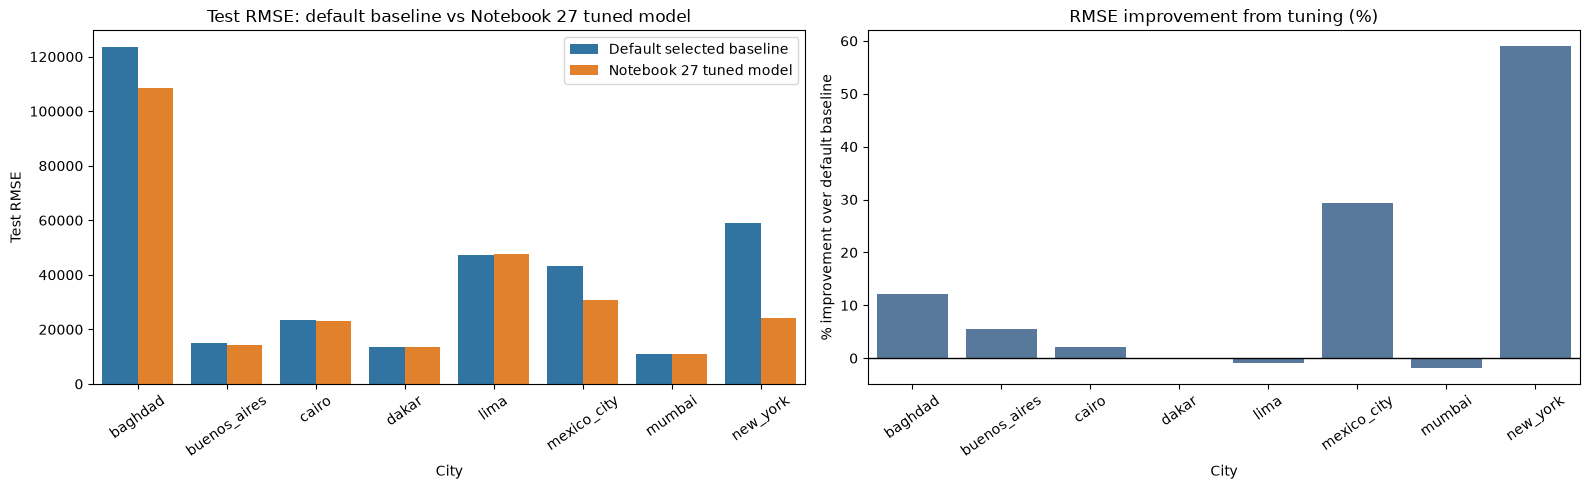

In [8]:
plot_df = compare_df.sort_values("city").copy()

long_rmse = plot_df.melt(
    id_vars=["city"],
    value_vars=["default_test_rmse", "tuned_main_test_rmse"],
    var_name="model_version",
    value_name="test_rmse",
)
long_rmse["model_version"] = long_rmse["model_version"].map({
    "default_test_rmse": "Default selected baseline",
    "tuned_main_test_rmse": "Main tuned model",
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=long_rmse, x="city", y="test_rmse", hue="model_version", ax=axes[0])
axes[0].set_title("Test RMSE: default baseline vs Main tuned model")
axes[0].set_xlabel("City")
axes[0].set_ylabel("Test RMSE")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title=None)

sns.barplot(data=plot_df, x="city", y="tuned_main_rmse_improvement_pct", ax=axes[1], color="#4C78A8")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("RMSE improvement from tuning (%)")
axes[1].set_xlabel("City")
axes[1].set_ylabel("% improvement over default baseline")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
figure_path = SCENARIO_OUTPUT_ROOT / "default_vs_tuned_main_rmse_comparison.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
print("Saved figure:", figure_path)
plt.show()


## 8. Interpretation Summary

This final section prints a short city-level interpretation. Use it to decide how to describe the baseline comparison in the report.

A useful reading rule is:

- if the tuned model improves RMSE in most cities, the tuning workflow is adding value overall;
- if the improvement is small or negative in a city, that city's performance may be driven more by the feature set and the temporal split than by hyperparameter tuning;
- even when a default baseline has lower test RMSE, it should be reported as a baseline result rather than used for post-hoc model selection based on the test set.


In [9]:
improved_cities = compare_df.loc[compare_df["tuning_helped_by_test_rmse"], "city"].tolist()
worse_cities = compare_df.loc[~compare_df["tuning_helped_by_test_rmse"], "city"].tolist()

print(f"Tuning improved test RMSE in {len(improved_cities)} / {len(compare_df)} cities.")
print("Improved cities:", improved_cities)
print("Default baseline was equal or better by test RMSE in:", worse_cities)

summary = compare_df[[
    "city", "default_selected_model", "tuned_main_selected_model",
    "tuned_main_rmse_improvement_pct", "tuned_main_mae_improvement_pct", "tuned_main_r2_gain"
]].copy()
summary["interpretation"] = np.where(
    summary["tuned_main_rmse_improvement_pct"] > 5,
    "tuning clearly improves RMSE",
    np.where(
        summary["tuned_main_rmse_improvement_pct"] > 0,
        "tuning slightly improves RMSE",
        "default baseline is competitive or better",
    ),
)
display(summary.sort_values("city"))


Tuning improved test RMSE in 5 / 8 cities.
Improved cities: ['baghdad', 'buenos_aires', 'cairo', 'mexico_city', 'new_york']
Default baseline was equal or better by test RMSE in: ['dakar', 'lima', 'mumbai']


,city,default_selected_model,tuned_main_selected_model,tuned_main_rmse_improvement_pct,tuned_main_mae_improvement_pct,tuned_main_r2_gain,interpretation
0,baghdad,hist_gradient_boosting_default,random_forest,12.214618,9.870147,0.073856,tuning clearly improves RMSE
1,buenos_aires,random_forest_default,xgboost,5.422971,-32.151146,0.011473,tuning clearly improves RMSE
2,cairo,random_forest_default,xgboost,2.019661,-0.935373,0.005945,tuning slightly improves RMSE
3,dakar,random_forest_default,xgboost,-0.091750,-2.226722,-0.000307,default baseline is competitive or better
4,lima,random_forest_default,random_forest,-0.904900,-1.329948,-0.003392,default baseline is competitive or better
5,mexico_city,xgboost_default,random_forest,29.323049,17.650256,0.087181,tuning clearly improves RMSE
6,mumbai,elastic_net_default,elastic_net,-1.826616,-2.457684,-0.027800,default baseline is competitive or better
7,new_york,elastic_net_default,random_forest,58.953998,59.925558,0.396792,tuning clearly improves RMSE
